## Elaboration d'une table de mortalité

## ⚙️ Classification & cartographie

### 1-Librairies et dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Data/2022-24-11_deces_quotidiens_departement_S10.csv", sep=";", encoding="ISO-8859-1")

# Conversion des dates
data["Date_evenement"] = pd.to_datetime(data["Date_evenement"], errors="coerce")

# Vérification rapide
print(data.head())

C:\Users\hp\AppData\Local\Temp\ipykernel_724\3147774276.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date_evenement"] = pd.to_datetime(data["Date_evenement"], errors="coerce")


  Date_evenement    Zone  Communes_a_envoi_dematerialise_Deces2022  \
0            NaT  France                                    1962.0   
1            NaT  France                                    3750.0   
2            NaT  France                                    5671.0   
3            NaT  France                                    7678.0   
4            NaT  France                                    9641.0   

   Total_deces_2022  Communes_a_envoi_dematerialise_Deces2021  \
0            2163.0                                      1937   
1            4144.0                                      3785   
2            6285.0                                      5730   
3            8503.0                                      7698   
4           10660.0                                      9676   

   Total_deces_2021  Communes_a_envoi_dematerialise_Deces2019  \
0              2145                                      1663   
1              4201                                      3

### 2-Agrégation par commune et par annnée

In [ ]:
# Extraction de l'année
data["Annee"] = data["Date_evenement"].dt.year

# Agrégation
agg = data.groupby(["Zone", "Communes_a_envoi_dematerialise_Deces2022"]).agg({
    "Total_deces_2022": "sum",
    "Total_deces_2021": "sum",
    "Total_deces_2019": "sum"
}).reset_index()

agg.head()

,Zone,Communes_a_envoi_dematerialise_Deces2022,Total_deces_2022,Total_deces_2021,Total_deces_2019
0,Dept_01,10.0,14.0,16,12
1,Dept_01,21.0,27.0,26,22
2,Dept_01,40.0,48.0,42,37
3,Dept_01,49.0,60.0,55,49
4,Dept_01,63.0,79.0,67,60


### 3-Construction des indicateurs

In [7]:
agg["Var_21_22"] = (agg["Total_deces_2022"] - agg["Total_deces_2021"]) / agg["Total_deces_2021"]
agg["Var_19_22"] = (agg["Total_deces_2022"] - agg["Total_deces_2019"]) / agg["Total_deces_2019"]

# Score simple de mortalité
agg["Score_mortalite"] = (
    agg["Total_deces_2022"] * 0.5 +
    agg["Total_deces_2021"] * 0.3 +
    agg["Total_deces_2019"] * 0.2
)

### 4-Cartographie

In [ ]:
import geopandas as gpd

geo = gpd.read_file("COMMUNE.shp")

print(geo.columns)
print(geo.head())

Index(['ID', 'NOM', 'NOM_M', 'INSEE_COM', 'STATUT', 'POPULATION', 'INSEE_CAN',
       'INSEE_ARR', 'INSEE_DEP', 'INSEE_REG', 'SIREN_EPCI', 'geometry'],
      dtype='object')
                         ID                         NOM  \
0  COMMUNE_0000000009760754            Lourties-Monbrun   
1  COMMUNE_0000000009756744         Boudy-de-Beauregard   
2  COMMUNE_0000000009754403  Autrans-Méaudre en Vercors   
3  COMMUNE_0000000009760252               Armous-et-Cau   
4  COMMUNE_0000000009727903                    Willeman   

                        NOM_M INSEE_COM          STATUT  POPULATION INSEE_CAN  \
0            LOURTIES-MONBRUN     32216  Commune simple         162        03   
1         BOUDY-DE-BEAUREGARD     47033  Commune simple         402        10   
2  AUTRANS-MEAUDRE EN VERCORS     38225  Commune simple        3075        07   
3               ARMOUS-ET-CAU     32009  Commune simple          93        16   
4                    WILLEMAN     62890  Commune simple         18

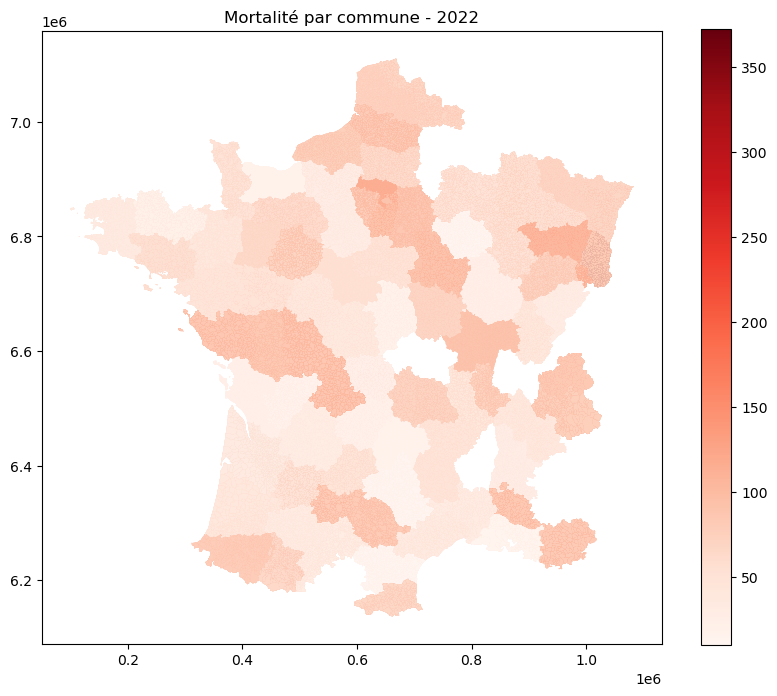

In [ ]:
geo["INSEE_DEP"] = geo["INSEE_DEP"].astype(str)
agg["Communes_a_envoi_dematerialise_Deces2022"] = (
    agg["Communes_a_envoi_dematerialise_Deces2022"].astype(int).astype(str)
)

# Jointure
merged = geo.merge(agg, left_on="INSEE_DEP", right_on="Communes_a_envoi_dematerialise_Deces2022")

# Carte choroplèthe
merged.plot(column="Total_deces_2022", cmap="Reds", legend=True, figsize=(10, 8))
plt.title("Mortalité par commune - 2022")
plt.show()

### 5-Classification ( K-means )

c:\Users\hp\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


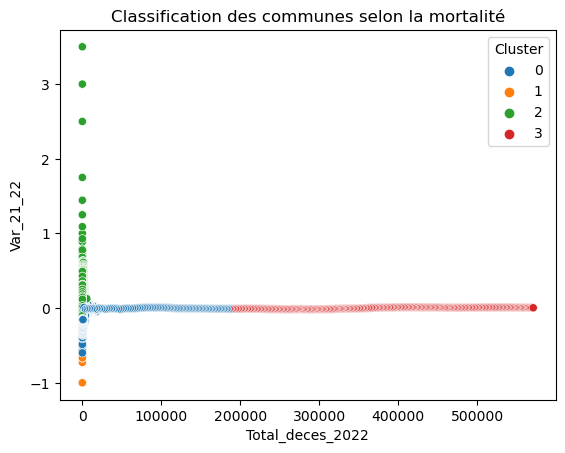

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

agg = agg.replace([np.inf, -np.inf], np.nan)

num_cols = agg.select_dtypes(include=[float, int]).columns

agg[num_cols] = agg[num_cols].fillna(0)

X = agg[["Total_deces_2022", "Var_21_22", "Var_19_22"]]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
agg["Cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=agg, x="Total_deces_2022", y="Var_21_22", hue="Cluster", palette="tab10")
plt.title("Classification des communes selon la mortalité")
plt.show()

### 6-Résumé

J’ai testé une classification K‑means pour segmenter les territoires, mais certains clusters reflétaient des artefacts de données plutôt que des profils réels.
La cartographie reste donc la représentation la plus fiable et la plus lisible pour comprendre les dynamiques de mortalité en France.
Elle met en évidence, en un coup d’œil, les départements en hausse, en baisse ou en stabilité.